# Tomato Disease Progression — Synthetic Dataset Generator

**Purpose:** Generate a single, comprehensive synthetic dataset for tomato disease progression  
modelling using an existing hourly greenhouse / crop-stage backbone as the environmental and temporal spine.

**Diseases simulated:** `early_blight`, `late_blight`, `leaf_mold`, `powdery_mildew`, `spider_mites`

**Design decision:** Future prediction targets (`predicted_infection_pct_24h`, `predicted_infection_pct_48h`, etc.) are  
**intentionally excluded** from this dataset. They will be created by a separate downstream process.

**Output:**
- One final CSV: `E:/AgriTwin-GH/data/processed/Disease Progression/tomato_disease_progression_synthetic_hourly.csv`
- One markdown doc: `E:/AgriTwin-GH/data/processed/Disease Progression/DISEASE_PROGRESSION_SYNTHETIC_DOCUMENTATION.md`

**Structure:**
- Section A – Imports and Configuration
- Section B – Load and Inspect Input Dataset
- Section C – Data Preparation and Time-Series Validation
- Section D – Disease Rule Definitions (Calibrated for Stronger Dynamics)
- Section E – Stage Susceptibility Mapping
- Section F – Outbreak Trigger Logic and Favorability Functions
- Section G – Disease Progression Simulation Engine (6-Phase Model)
- Section H – Dataset Design Notes (Targets Excluded)
- Section I – Final Dataset Assembly and Validation
- Section J – Save Outputs
- Section K – Summary and Sanity Checks


---
## Section A — Imports and Configuration

In [1]:
# ============================================================
# SECTION A: Imports and Configuration
# ============================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# ── File Paths ────────────────────────────────────────────────
INPUT_CSV = Path(
    "E:/AgriTwin-GH/data/processed/Growth Progression/"
    "tomato_growth_progression_synthetic_hourly.csv"
)
OUTPUT_DIR = Path("E:/AgriTwin-GH/data/processed/Disease Progression")
OUTPUT_CSV = OUTPUT_DIR / "tomato_disease_progression_synthetic_hourly.csv"
OUTPUT_MD  = OUTPUT_DIR / "DISEASE_PROGRESSION_SYNTHETIC_DOCUMENTATION.md"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input CSV  : {INPUT_CSV}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Output CSV : {OUTPUT_CSV.name}")
print(f"Output MD  : {OUTPUT_MD.name}")

# ── Disease list ──────────────────────────────────────────────
DISEASES = [
    "early_blight",
    "late_blight",
    "leaf_mold",
    "powdery_mildew",
    "spider_mites",
]

print(f"\nDiseases to simulate: {DISEASES}")

Input CSV  : E:\AgriTwin-GH\data\processed\Growth Progression\tomato_growth_progression_synthetic_hourly.csv
Output dir : E:\AgriTwin-GH\data\processed\Disease Progression
Output CSV : tomato_disease_progression_synthetic_hourly.csv
Output MD  : DISEASE_PROGRESSION_SYNTHETIC_DOCUMENTATION.md

Diseases to simulate: ['early_blight', 'late_blight', 'leaf_mold', 'powdery_mildew', 'spider_mites']


---
## Section B — Load and Inspect Input Dataset

In [2]:
# ============================================================
# SECTION B: Load and Inspect Input Dataset
# ============================================================

df_raw = pd.read_csv(INPUT_CSV)

print(f"Shape      : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nAll columns and dtypes:")
for col in df_raw.columns:
    print(f"  {col:<45} {str(df_raw[col].dtype):<12} | sample: {df_raw[col].iloc[0]}")

print("\nGrowth stage distribution:")
print(df_raw["stage_name"].value_counts())

# Check key environmental columns
env_cols = ["indoor_temp", "indoor_humidity", "indoor_air_velocity",
            "vpd", "leaf_wetness_proxy", "dew_point"]
env_cols_available = [c for c in env_cols if c in df_raw.columns]
print("\nEnvironmental column stats:")
print(df_raw[env_cols_available].describe().round(3))

Shape      : 10,848 rows × 37 columns

All columns and dtypes:
  timestamp                                     object       | sample: 2024-07-01 00:00:00
  cycle_id                                      int64        | sample: 1
  cycle_label                                   object       | sample: kharif_2024
  season_window                                 object       | sample: Kharif (Jun–Jul 2024)
  real_or_synthetic_flag                        object       | sample: synthetic
  year                                          int64        | sample: 2024
  month                                         int64        | sample: 7
  day_of_year                                   int64        | sample: 183
  week_of_year                                  int64        | sample: 27
  hour                                          int64        | sample: 0
  season_label                                  object       | sample: southwest_monsoon
  days_from_cycle_start                         float64 

---
## Section C — Data Preparation and Time-Series Validation

In [3]:
# ============================================================
# SECTION C: Data Preparation and Time-Series Validation
# ============================================================

# ── 1. Flexible column discovery ──────────────────────────────
# Maps a canonical column name to a list of possible source column names.
# The first match found in df_raw.columns is used.
EXPECTED_COLS = {
    "timestamp"                   : ["timestamp", "time", "datetime", "date"],
    "stage_name"                  : ["stage_name", "growth_stage", "crop_stage"],
    "indoor_temp"                 : ["indoor_temp", "temperature", "temp_c", "temp"],
    "indoor_humidity"             : ["indoor_humidity", "humidity", "rh", "relative_humidity"],
    "indoor_air_velocity"         : ["indoor_air_velocity", "air_velocity", "airflow", "wind_speed"],
    "indoor_CO2"                  : ["indoor_CO2", "co2", "co2_ppm"],
    "solarradiation"              : ["solarradiation", "solar_radiation", "radiation", "par"],
    "vpd"                         : ["vpd", "vpd_proxy", "vapor_pressure_deficit"],
    "dew_point"                   : ["dew_point", "dewpoint"],
    "leaf_wetness_proxy"          : ["leaf_wetness_proxy", "leaf_wetness"],
    "temperature_rolling_mean_24h": ["temperature_rolling_mean_24h"],
    "humidity_rolling_mean_24h"   : ["humidity_rolling_mean_24h"],
    "cycle_id"                    : ["cycle_id"],
    "cycle_label"                 : ["cycle_label"],
}

def find_column(df, candidates):
    """Return the first candidate name found as a column in df, else None."""
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

col_map = {}
print("Column discovery results:")
for canonical, candidates in EXPECTED_COLS.items():
    found = find_column(df_raw, candidates)
    col_map[canonical] = found
    status = f"OK  → '{found}'" if found else "MISS → using default"
    print(f"  {canonical:<40} {status}")

# ── 2. Build working copy ─────────────────────────────────────
df = df_raw.copy()

ts_col = col_map["timestamp"]
if ts_col is None:
    raise ValueError("Timestamp column is required but was not found. Check input CSV.")

df["timestamp"] = pd.to_datetime(df[ts_col], errors="coerce")
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"\nTimestamp range : {df['timestamp'].iloc[0]}  →  {df['timestamp'].iloc[-1]}")
print(f"Total rows      : {len(df):,}")

# ── 3. Hourly continuity validation ───────────────────────────
time_diffs   = df["timestamp"].diff().dropna()
expected_gap = pd.Timedelta("1H")
irregulars   = (time_diffs != expected_gap).sum()
print(f"Irregular time gaps (should be 0 or few): {irregulars}")
if irregulars > 0:
    print("  Note: Gaps may align with cycle boundary transitions — acceptable.")

# ── 4. Derived / fallback columns ─────────────────────────────
# Leaf wetness proxy: if missing, derive from humidity > 95%
if col_map["leaf_wetness_proxy"] is None:
    hum_col = col_map["indoor_humidity"]
    if hum_col:
        df["leaf_wetness_proxy"] = (df[hum_col] > 95.0).astype(float)
        col_map["leaf_wetness_proxy"] = "leaf_wetness_proxy"
        print("Derived leaf_wetness_proxy from humidity > 95%.")
    else:
        df["leaf_wetness_proxy"] = 0.0
        col_map["leaf_wetness_proxy"] = "leaf_wetness_proxy"
        print("leaf_wetness_proxy defaulted to 0.")

# VPD: if missing, try vpd_proxy or default
if col_map["vpd"] is None:
    if "vpd_proxy" in df.columns:
        col_map["vpd"] = "vpd_proxy"
        print("Using vpd_proxy as vpd surrogate.")
    else:
        df["vpd"] = 1.2  # neutral default kPa
        col_map["vpd"] = "vpd"
        print("vpd defaulted to 1.2 kPa.")

print(f"\nFinal working dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns")
missing = df.isnull().sum()[df.isnull().sum() > 0]
if len(missing):
    print("Missing value counts:")
    print(missing)
else:
    print("No missing values in backbone columns.")

Column discovery results:
  timestamp                                OK  → 'timestamp'
  stage_name                               OK  → 'stage_name'
  indoor_temp                              OK  → 'indoor_temp'
  indoor_humidity                          OK  → 'indoor_humidity'
  indoor_air_velocity                      OK  → 'indoor_air_velocity'
  indoor_CO2                               OK  → 'indoor_CO2'
  solarradiation                           OK  → 'solarradiation'
  vpd                                      OK  → 'vpd'
  dew_point                                OK  → 'dew_point'
  leaf_wetness_proxy                       OK  → 'leaf_wetness_proxy'
  temperature_rolling_mean_24h             OK  → 'temperature_rolling_mean_24h'
  humidity_rolling_mean_24h                OK  → 'humidity_rolling_mean_24h'
  cycle_id                                 OK  → 'cycle_id'
  cycle_label                              OK  → 'cycle_label'

Timestamp range : 2024-07-01 00:00:00  →  2025-10-21 23

---
## Section D — Disease Rule Definitions

Each disease is characterised by:
- **Optimal and stress ranges** for temperature, humidity, and VPD
- **Leaf wetness bonus** (or penalty for spider mites)
- **Airflow penalty** above a threshold velocity
- **Logistic growth rate** `r` (per hour)
- **Decline rate** and **intervention reduction factor**

Favorability = weighted mean of individual factor scores, each computed via piecewise-linear interpolation between stress bounds (0) and optimal range (1).

In [4]:
# ============================================================
# SECTION D: Disease Rule Definitions
# ============================================================
# Growth rates are calibrated so severe cycles can reach 80-95% infection
# within a realistic 4-6 week outbreak window in a greenhouse setting.
# Decline rates create a ~2-3 week natural cleardown.

DISEASE_CONFIG = {
    "early_blight": {
        # Alternaria solani — warm (25–32 °C), moderate-high humidity, leaf wetness accelerates sporulation
        "temp_opt"               : (25.0, 32.0),
        "temp_stress"            : (14.0, 38.0),
        "hum_opt"                : (55.0, 80.0),
        "hum_stress"             : (35.0, 96.0),
        "vpd_opt"                : (0.7,  2.0),
        "vpd_stress"             : (0.2,  3.5),
        "lw_bonus"               : 0.22,
        "airflow_penalty_above"  : 2.8,
        "airflow_penalty_factor" : 0.68,
        "weights"                : {"temp": 0.40, "hum": 0.35, "vpd": 0.25},
        "base_growth_rate"       : 0.18,   # ~0.07 prev → 0.18 for realistic aggressive spread
        "decline_rate"           : 0.042,
        "intervention_reduction" : 0.62,
        "min_trigger_favorability": 0.40,
    },
    "late_blight": {
        # Phytophthora infestans — cool (10–22 °C), very high humidity; leaf wetness critical
        "temp_opt"               : (10.0, 22.0),
        "temp_stress"            : ( 3.0, 28.0),
        "hum_opt"                : (85.0, 100.0),
        "hum_stress"             : (65.0, 100.0),
        "vpd_opt"                : (0.0,  0.6),
        "vpd_stress"             : (0.0,  1.6),
        "lw_bonus"               : 0.30,
        "airflow_penalty_above"  : 2.2,
        "airflow_penalty_factor" : 0.60,
        "weights"                : {"temp": 0.35, "hum": 0.45, "vpd": 0.20},
        "base_growth_rate"       : 0.22,   # Very aggressive — destroys crops fast under right conditions
        "decline_rate"           : 0.048,
        "intervention_reduction" : 0.68,
        "min_trigger_favorability": 0.45,
    },
    "leaf_mold": {
        # Passalora fulva — needs persistently high humidity and poor airflow; dense canopy
        "temp_opt"               : (16.0, 24.0),
        "temp_stress"            : ( 9.0, 32.0),
        "hum_opt"                : (82.0, 100.0),
        "hum_stress"             : (62.0, 100.0),
        "vpd_opt"                : (0.0,  0.5),
        "vpd_stress"             : (0.0,  1.3),
        "lw_bonus"               : 0.28,
        "airflow_penalty_above"  : 1.8,
        "airflow_penalty_factor" : 0.50,
        "weights"                : {"temp": 0.30, "hum": 0.50, "vpd": 0.20},
        "base_growth_rate"       : 0.16,   # Moderate-high; humidity-gated
        "decline_rate"           : 0.038,
        "intervention_reduction" : 0.58,
        "min_trigger_favorability": 0.42,
    },
    "powdery_mildew": {
        # Leveillula taurica — moderate temp and humidity; dry leaf surface preferred; windborne spores
        "temp_opt"               : (20.0, 28.0),
        "temp_stress"            : (11.0, 36.0),
        "hum_opt"                : (40.0, 70.0),
        "hum_stress"             : (22.0, 86.0),
        "vpd_opt"                : (0.6,  1.8),
        "vpd_stress"             : (0.2,  3.2),
        "lw_bonus"               : 0.00,   # dry leaf preferred; no bonus
        "airflow_penalty_above"  : 3.8,
        "airflow_penalty_factor" : 0.82,
        "weights"                : {"temp": 0.42, "hum": 0.33, "vpd": 0.25},
        "base_growth_rate"       : 0.14,   # Steady, persistent spreader
        "decline_rate"           : 0.032,
        "intervention_reduction" : 0.58,
        "min_trigger_favorability": 0.36,
    },
    "spider_mites": {
        # Tetranychus urticae — hot (28–38 °C), dry conditions; leaf wetness inhibits
        "temp_opt"               : (28.0, 38.0),
        "temp_stress"            : (20.0, 44.0),
        "hum_opt"                : (28.0, 52.0),
        "hum_stress"             : (18.0, 72.0),
        "vpd_opt"                : (2.0,  4.5),
        "vpd_stress"             : (0.8,  6.0),
        "lw_bonus"               : -0.18,  # leaf wetness strongly inhibits mites
        "airflow_penalty_above"  : 99.0,   # airflow not a limiter for mites
        "airflow_penalty_factor" : 1.00,
        "weights"                : {"temp": 0.45, "hum": 0.38, "vpd": 0.17},
        "base_growth_rate"       : 0.20,   # Fast population buildup in dry heat
        "decline_rate"           : 0.044,
        "intervention_reduction" : 0.62,
        "min_trigger_favorability": 0.38,
    },
}

print("Disease configurations loaded:")
print(f"  {'Disease':<20} {'r (growth)':<12} {'decline':<10} {'temp_opt':<18} {'hum_opt'}")
print("  " + "─" * 72)
for d, cfg in DISEASE_CONFIG.items():
    print(f"  {d:<20} {cfg['base_growth_rate']:<12.3f} {cfg['decline_rate']:<10.3f} "
          f"{str(cfg['temp_opt']):<18} {cfg['hum_opt']}")


Disease configurations loaded:
  Disease              r (growth)   decline    temp_opt           hum_opt
  ────────────────────────────────────────────────────────────────────────
  early_blight         0.180        0.042      (25.0, 32.0)       (55.0, 80.0)
  late_blight          0.220        0.048      (10.0, 22.0)       (85.0, 100.0)
  leaf_mold            0.160        0.038      (16.0, 24.0)       (82.0, 100.0)
  powdery_mildew       0.140        0.032      (20.0, 28.0)       (40.0, 70.0)
  spider_mites         0.200        0.044      (28.0, 38.0)       (28.0, 52.0)


---
## Section E — Stage Susceptibility Mapping

Each growth stage is assigned a susceptibility score ∈ [0, 1] per disease.  
During simulation, this score multiplies the net growth rate — higher susceptibility → faster disease spread.  
Scores reflect tomato pathology literature and greenhouse crop-disease interactions.

In [5]:
# ============================================================
# SECTION E: Stage Susceptibility Mapping
# ============================================================

# Growth stages present in the input dataset:
KNOWN_STAGES = [
    "seedling",
    "early_vegetative",
    "flowering_initiation",
    "flowering",
    "unripe",
    "ripe",
]

STAGE_SUSCEPTIBILITY = {
    "early_blight": {
        # Alternaria solani is most severe on mature/older lower leaves
        "seedling"             : 0.35,
        "early_vegetative"     : 0.55,
        "flowering_initiation" : 0.72,
        "flowering"            : 0.85,
        "unripe"               : 0.88,
        "ripe"                 : 0.60,
    },
    "late_blight": {
        # Phytophthora infestans is extremely destructive; peaks at fruit stages
        "seedling"             : 0.45,
        "early_vegetative"     : 0.60,
        "flowering_initiation" : 0.78,
        "flowering"            : 0.90,
        "unripe"               : 0.92,
        "ripe"                 : 0.55,
    },
    "leaf_mold": {
        # Passalora fulva is primarily a foliar disease; peaks at dense canopy stages
        "seedling"             : 0.30,
        "early_vegetative"     : 0.50,
        "flowering_initiation" : 0.68,
        "flowering"            : 0.88,
        "unripe"               : 0.80,
        "ripe"                 : 0.45,
    },
    "powdery_mildew": {
        # Young leaves most susceptible; resistance tends to increase at fruit stages
        "seedling"             : 0.50,
        "early_vegetative"     : 0.70,
        "flowering_initiation" : 0.78,
        "flowering"            : 0.82,
        "unripe"               : 0.65,
        "ripe"                 : 0.40,
    },
    "spider_mites": {
        # Mid-to-late canopy; high impact at vegetative through unripe stages
        "seedling"             : 0.40,
        "early_vegetative"     : 0.62,
        "flowering_initiation" : 0.75,
        "flowering"            : 0.85,
        "unripe"               : 0.80,
        "ripe"                 : 0.50,
    },
}

# Fallback for any stage not in the table
DEFAULT_SUSCEPTIBILITY = 0.50

# Display as a DataFrame for review
susc_df = pd.DataFrame(STAGE_SUSCEPTIBILITY, index=KNOWN_STAGES)
print("Stage Susceptibility Table (rows = growth stages, cols = diseases):")
print(susc_df.to_string())

Stage Susceptibility Table (rows = growth stages, cols = diseases):
                      early_blight  late_blight  leaf_mold  powdery_mildew  spider_mites
seedling                      0.35         0.45       0.30            0.50          0.40
early_vegetative              0.55         0.60       0.50            0.70          0.62
flowering_initiation          0.72         0.78       0.68            0.78          0.75
flowering                     0.85         0.90       0.88            0.82          0.85
unripe                        0.88         0.92       0.80            0.65          0.80
ripe                          0.60         0.55       0.45            0.40          0.50


---
## Section F — Outbreak Trigger Logic and Favorability Functions

**Favorability formula** (per disease per hour):
```
fav = w_temp × temp_score + w_hum × hum_score + w_vpd × vpd_score
fav += lw_bonus × leaf_wetness_proxy
fav *= airflow_penalty_factor   (when air_velocity > threshold)
fav = clip(fav, 0, 1)
```

Each individual score uses **piecewise-linear interpolation**:
- Score = 1.0 inside the optimal range
- Score tapers linearly from 1 → 0 between optimal edge and stress bound
- Score = 0.0 beyond stress bounds

**Outbreak seeding:** Six pre-planned outbreak cycles are scheduled per disease at specific row indices,  
spanning all four growing seasons (kharif_2024, rabi_2024, summer_2025, kharif_2025).  
Each disease gets **2 mild + 2 moderate + 2 severe** cycles for training diversity.  
Severe cycles have higher logistic carrying capacity K (65–95%) for strong upper-severity coverage.


In [6]:
# ============================================================
# SECTION F: Outbreak Trigger Logic and Favorability Functions
# ============================================================

# ── Piecewise-linear environmental score ─────────────────────
def piecewise_linear_score(value, opt_low, opt_high, stress_low, stress_high):
    """
    Compute favorability of a single environmental variable.
    Returns a float in [0, 1]:
      - 1.0 within [opt_low, opt_high]
      - Linearly decreasing toward 0 between optimal edge and stress bound
      - 0.0 at or beyond stress bounds
    """
    if opt_low <= value <= opt_high:
        return 1.0
    elif value < opt_low:
        if value <= stress_low:
            return 0.0
        return (value - stress_low) / (opt_low - stress_low)
    else:
        if value >= stress_high:
            return 0.0
        return (stress_high - value) / (stress_high - opt_high)


# ── Combined environmental favorability ───────────────────────
def compute_favorability(row, disease_name, disease_config, col_map):
    """
    Compute the net environmental favorability score ∈ [0, 1] for a disease
    given a single row of greenhouse data.
    """
    cfg = disease_config[disease_name]
    w   = cfg["weights"]

    temp_col = col_map.get("indoor_temp")
    temp_val = float(row[temp_col]) if temp_col and temp_col in row.index else 28.0
    t_score  = piecewise_linear_score(
        temp_val, cfg["temp_opt"][0], cfg["temp_opt"][1],
        cfg["temp_stress"][0], cfg["temp_stress"][1],
    )

    hum_col = col_map.get("indoor_humidity")
    hum_val = float(row[hum_col]) if hum_col and hum_col in row.index else 70.0
    h_score = piecewise_linear_score(
        hum_val, cfg["hum_opt"][0], cfg["hum_opt"][1],
        cfg["hum_stress"][0], cfg["hum_stress"][1],
    )

    vpd_col = col_map.get("vpd") or "vpd"
    vpd_val = float(row[vpd_col]) if vpd_col in row.index else 1.2
    v_score = piecewise_linear_score(
        vpd_val, cfg["vpd_opt"][0], cfg["vpd_opt"][1],
        cfg["vpd_stress"][0], cfg["vpd_stress"][1],
    )

    fav = w["temp"] * t_score + w["hum"] * h_score + w["vpd"] * v_score

    lw_col = col_map.get("leaf_wetness_proxy") or "leaf_wetness_proxy"
    lw_val = float(row[lw_col]) if lw_col in row.index else 0.0
    fav   += cfg["lw_bonus"] * lw_val
    fav    = max(fav, 0.0)

    av_col = col_map.get("indoor_air_velocity") or "indoor_air_velocity"
    av_val = float(row[av_col]) if av_col in row.index else 2.0
    if av_val > cfg["airflow_penalty_above"]:
        fav *= cfg["airflow_penalty_factor"]

    return float(np.clip(fav, 0.0, 1.0))


# ── Vectorised favorability computation ──────────────────────
def compute_favorability_array(df, disease_name, disease_config, col_map):
    """
    Compute favorability scores for all rows at once using numpy vectorisation.
    Returns a 1-D numpy array of length len(df).
    """
    cfg = disease_config[disease_name]
    w   = cfg["weights"]

    def _col(key, default):
        c = col_map.get(key)
        return df[c].to_numpy(dtype=float) if (c and c in df.columns) else np.full(len(df), default)

    temp_arr = _col("indoor_temp",         28.0)
    hum_arr  = _col("indoor_humidity",     70.0)
    vpd_arr  = _col("vpd",                 1.2)
    lw_arr   = _col("leaf_wetness_proxy",   0.0)
    av_arr   = _col("indoor_air_velocity",  2.0)

    def vec_score(arr, ol, oh, sl, sh):
        return np.where(arr < ol,
                   np.where(arr <= sl, 0.0, (arr - sl) / (ol - sl)),
                   np.where(arr > oh,
                       np.where(arr >= sh, 0.0, (sh - arr) / (sh - oh)),
                       1.0))

    t_score = vec_score(temp_arr, cfg["temp_opt"][0], cfg["temp_opt"][1],
                        cfg["temp_stress"][0], cfg["temp_stress"][1])
    h_score = vec_score(hum_arr,  cfg["hum_opt"][0],  cfg["hum_opt"][1],
                        cfg["hum_stress"][0],  cfg["hum_stress"][1])
    v_score = vec_score(vpd_arr,  cfg["vpd_opt"][0],  cfg["vpd_opt"][1],
                        cfg["vpd_stress"][0],  cfg["vpd_stress"][1])

    fav = w["temp"] * t_score + w["hum"] * h_score + w["vpd"] * v_score
    fav += cfg["lw_bonus"] * lw_arr
    fav  = np.maximum(fav, 0.0)

    airflow_mask = av_arr > cfg["airflow_penalty_above"]
    fav[airflow_mask] *= cfg["airflow_penalty_factor"]

    return np.clip(fav, 0.0, 1.0)


# ── Pre-planned outbreak seed positions ───────────────────────
# Timeline row coverage (approximate):
#   cycle kharif_2024  : rows    0 – 2711   (2024-07-01 → 2024-10-21)
#   cycle rabi_2024    : rows 2712 – 5327   (2024-11-10 → 2025-02-26)
#   cycle summer_2025  : rows 5328 – 8135   (2025-03-05 → 2025-06-29)
#   cycle kharif_2025  : rows 8136 – 10847  (2025-07-01 → 2025-10-21)
#
# Each disease receives 6 seeds: 2 mild + 2 moderate + 2 severe.
# Severe cycles use high peak_severity (K) values to train the model on upper-severity dynamics.
# max_duration_hours sets the hard cap on how long each cycle can run.

OUTBREAK_SEEDS = {
    "early_blight": [
        # kharif_2024: mild long, then severe mid-season
        {"start_idx":  300, "initial_seed": 0.8, "peak_severity": 16.0,
         "severity_category": "mild",     "max_duration_hours": 420},
        {"start_idx": 1400, "initial_seed": 2.0, "peak_severity": 82.0,
         "severity_category": "severe",   "max_duration_hours": 1080},
        # rabi_2024: moderate
        {"start_idx": 3100, "initial_seed": 1.0, "peak_severity": 38.0,
         "severity_category": "moderate", "max_duration_hours": 580},
        # summer_2025: severe early, then mild late
        {"start_idx": 5600, "initial_seed": 2.5, "peak_severity": 91.0,
         "severity_category": "severe",   "max_duration_hours": 1150},
        {"start_idx": 7600, "initial_seed": 0.6, "peak_severity": 20.0,
         "severity_category": "mild",     "max_duration_hours": 440},
        # kharif_2025: moderate
        {"start_idx": 9200, "initial_seed": 1.4, "peak_severity": 46.0,
         "severity_category": "moderate", "max_duration_hours": 620},
    ],
    "late_blight": [
        # kharif_2024: severe (cool nights, high humidity)
        {"start_idx":  420, "initial_seed": 1.5, "peak_severity": 78.0,
         "severity_category": "severe",   "max_duration_hours": 1040},
        # rabi_2024: mild, then moderate
        {"start_idx": 3000, "initial_seed": 0.5, "peak_severity": 14.0,
         "severity_category": "mild",     "max_duration_hours": 360},
        {"start_idx": 4200, "initial_seed": 1.2, "peak_severity": 42.0,
         "severity_category": "moderate", "max_duration_hours": 600},
        # summer_2025: mild
        {"start_idx": 6400, "initial_seed": 0.6, "peak_severity": 18.0,
         "severity_category": "mild",     "max_duration_hours": 400},
        # kharif_2025: severe, then moderate
        {"start_idx": 8100, "initial_seed": 2.2, "peak_severity": 88.0,
         "severity_category": "severe",   "max_duration_hours": 1120},
        {"start_idx": 9700, "initial_seed": 1.0, "peak_severity": 36.0,
         "severity_category": "moderate", "max_duration_hours": 540},
    ],
    "leaf_mold": [
        # kharif_2024: severe (dense early canopy), then mild
        {"start_idx":  200, "initial_seed": 1.8, "peak_severity": 74.0,
         "severity_category": "severe",   "max_duration_hours": 1000},
        {"start_idx": 2200, "initial_seed": 0.7, "peak_severity": 19.0,
         "severity_category": "mild",     "max_duration_hours": 420},
        # rabi_2024: moderate
        {"start_idx": 3800, "initial_seed": 1.2, "peak_severity": 44.0,
         "severity_category": "moderate", "max_duration_hours": 620},
        # summer_2025: severe
        {"start_idx": 5800, "initial_seed": 2.0, "peak_severity": 86.0,
         "severity_category": "severe",   "max_duration_hours": 1100},
        # kharif_2025: mild, then moderate
        {"start_idx": 8300, "initial_seed": 0.5, "peak_severity": 15.0,
         "severity_category": "mild",     "max_duration_hours": 380},
        {"start_idx": 9800, "initial_seed": 1.3, "peak_severity": 40.0,
         "severity_category": "moderate", "max_duration_hours": 560},
    ],
    "powdery_mildew": [
        # kharif_2024: mild, then severe
        {"start_idx":  650, "initial_seed": 0.7, "peak_severity": 21.0,
         "severity_category": "mild",     "max_duration_hours": 450},
        {"start_idx": 1900, "initial_seed": 2.2, "peak_severity": 85.0,
         "severity_category": "severe",   "max_duration_hours": 1100},
        # rabi_2024: moderate
        {"start_idx": 3600, "initial_seed": 1.0, "peak_severity": 40.0,
         "severity_category": "moderate", "max_duration_hours": 580},
        # summer_2025: severe
        {"start_idx": 6000, "initial_seed": 2.0, "peak_severity": 92.0,
         "severity_category": "severe",   "max_duration_hours": 1150},
        # kharif_2025: mild, moderate
        {"start_idx": 7900, "initial_seed": 0.8, "peak_severity": 18.0,
         "severity_category": "mild",     "max_duration_hours": 430},
        {"start_idx": 9400, "initial_seed": 1.5, "peak_severity": 44.0,
         "severity_category": "moderate", "max_duration_hours": 600},
    ],
    "spider_mites": [
        # kharif_2024: severe (hot, dry summer), then mild
        {"start_idx":  350, "initial_seed": 2.0, "peak_severity": 80.0,
         "severity_category": "severe",   "max_duration_hours": 1060},
        {"start_idx": 2000, "initial_seed": 0.6, "peak_severity": 17.0,
         "severity_category": "mild",     "max_duration_hours": 400},
        # rabi_2024: moderate
        {"start_idx": 3700, "initial_seed": 1.2, "peak_severity": 42.0,
         "severity_category": "moderate", "max_duration_hours": 600},
        # summer_2025: severe
        {"start_idx": 6100, "initial_seed": 2.5, "peak_severity": 93.0,
         "severity_category": "severe",   "max_duration_hours": 1200},
        # kharif_2025: moderate, then mild
        {"start_idx": 8000, "initial_seed": 1.3, "peak_severity": 46.0,
         "severity_category": "moderate", "max_duration_hours": 640},
        {"start_idx": 9900, "initial_seed": 0.5, "peak_severity": 16.0,
         "severity_category": "mild",     "max_duration_hours": 380},
    ],
}

print("Outbreak seeds scheduled (6 per disease: 2 mild + 2 moderate + 2 severe):")
print(f"  {'Disease':<20} {'Rows':>24}   {'Categories':<42} {'K (peaks)'}")
print("  " + "─" * 108)
for disease, seeds in OUTBREAK_SEEDS.items():
    row_ids = [s["start_idx"] for s in seeds]
    cats    = [s["severity_category"] for s in seeds]
    peaks   = [s["peak_severity"] for s in seeds]
    print(f"  {disease:<20} {str(row_ids):<28}  {str(cats):<42} {peaks}")


Outbreak seeds scheduled (6 per disease: 2 mild + 2 moderate + 2 severe):
  Disease                                  Rows   Categories                                 K (peaks)
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────
  early_blight         [300, 1400, 3100, 5600, 7600, 9200]  ['mild', 'severe', 'moderate', 'severe', 'mild', 'moderate'] [16.0, 82.0, 38.0, 91.0, 20.0, 46.0]
  late_blight          [420, 3000, 4200, 6400, 8100, 9700]  ['severe', 'mild', 'moderate', 'mild', 'severe', 'moderate'] [78.0, 14.0, 42.0, 18.0, 88.0, 36.0]
  leaf_mold            [200, 2200, 3800, 5800, 8300, 9800]  ['severe', 'mild', 'moderate', 'severe', 'mild', 'moderate'] [74.0, 19.0, 44.0, 86.0, 15.0, 40.0]
  powdery_mildew       [650, 1900, 3600, 6000, 7900, 9400]  ['mild', 'severe', 'moderate', 'severe', 'mild', 'moderate'] [21.0, 85.0, 40.0, 92.0, 18.0, 44.0]
  spider_mites         [350, 2000, 3700, 6100, 8000, 9900]  ['severe', 'mild', '

---
## Section G — Disease Progression Simulation Engine (6-Phase Model)

Each outbreak cycle advances through up to **six sequential phases**:

| Phase            | Entry Condition                                                | Growth Behaviour                                              |
|------------------|----------------------------------------------------------------|---------------------------------------------------------------|
| `latent`         | Cycle seed injected                                            | Very slow fixed growth; pathogen establishing                 |
| `onset`          | elapsed ≥ 24 h **or** infection ≥ 2.5%                        | Moderate logistic growth at 50% of full rate                  |
| `spread`         | infection ≥ max(12% of K, 5%)                                  | Full aggressive logistic growth; strongly env-responsive      |
| `severe`         | infection ≥ 70% of K                                           | Fluctuation near K; control events create downward pressure  |
| `stabilization`  | elapsed ≥ 76% of max_duration **or** 24 h of low env. fav.    | Gentle decline from peak; conditions no longer sustain K      |
| `decline`        | elapsed ≥ 88% of max_duration                                  | Exponential decay until infection < 0.5% (cycle ends)        |

### Core Logistic Growth (spread phase):
$$\Delta I = r \cdot I \cdot \left(1 - \frac{I}{K}\right) \cdot fav^{0.80} \cdot susc$$

The `fav^0.80` exponent means low favorability still allows slow spread while high favorability  
creates rapid acceleration — more realistic than a linear fav term.

### Control Action Policy
- Trigger threshold: `current_infection_pct ≥ 15%` (down from 30% previously)
- Probability per eligible hour: 35%
- Multiple events per cycle are supported with a 72-hour cooldown between events
- Each event stays active for 48 hours, reducing growth increment by `intervention_reduction` and  
  increasing decline rate by 2.5×


In [7]:
# ============================================================
# SECTION G: Disease Progression Simulation Engine (6-Phase Model)
# ============================================================

# Control action configuration
CONTROL_ACTION_TYPES = {
    "early_blight"   : ["fungicide_spray",       "copper_treatment",      "reduced_irrigation"],
    "late_blight"    : ["fungicide_spray",        "ventilation_increase",  "humidity_reduction"],
    "leaf_mold"      : ["ventilation_increase",   "humidity_reduction",    "leaf_pruning"],
    "powdery_mildew" : ["sulfur_treatment",       "potassium_bicarbonate", "improved_airflow"],
    "spider_mites"   : ["acaricide_spray",        "humidity_increase",     "biological_release"],
}

CONTROL_ACTIVE_HOURS   = 48    # duration each control event stays active
CONTROL_COOLDOWN_HOURS = 72    # min hours between consecutive events (per cycle)
CONTROL_TRIGGER_LEVEL  = 15.0  # min infection % to become eligible for control


def simulate_disease(df, disease_name, disease_config, stage_susceptibility,
                     outbreak_seeds, col_map, rng_instance):
    """
    Simulate hourly disease progression for one disease over the full timeline
    using a 6-phase finite-state model: latent → onset → spread → severe →
    stabilization → decline.

    Returns
    -------
    dict of 1-D arrays, each length len(df)
    """
    n   = len(df)
    cfg = disease_config[disease_name]

    # ── Pre-compute all favorability and susceptibility scores ─
    fav_arr      = compute_favorability_array(df, disease_name, disease_config, col_map)
    stage_series = df["stage_name"].tolist() if "stage_name" in df.columns \
                   else ["early_vegetative"] * n
    stage_susc   = stage_susceptibility.get(disease_name, {})
    susc_arr     = np.array([stage_susc.get(s, DEFAULT_SUSCEPTIBILITY) for s in stage_series])
    risk_arr     = np.round(fav_arr * susc_arr, 4)

    # ── Output arrays ─────────────────────────────────────────
    infection     = np.zeros(n, dtype=float)
    hours_onset   = np.full(n, np.nan, dtype=float)
    cycle_id_arr  = np.zeros(n, dtype=int)
    cycle_stg_arr = np.full(n, "none", dtype=object)
    ob_trigger    = np.zeros(n, dtype=bool)
    ctrl_action   = np.zeros(n, dtype=bool)
    ctrl_type_arr = np.full(n, "none", dtype=object)
    growth_rate   = np.zeros(n, dtype=float)

    # ── Outbreak seed lookup ──────────────────────────────────
    seeds_by_idx = {s["start_idx"]: s for s in outbreak_seeds}

    # ── Cycle state variables ─────────────────────────────────
    current_cycle    = None   # active cycle dict, or None
    current_cycle_id = 0
    onset_idx        = 0
    last_ctrl_start  = -9999  # most recent control event start row
    action_pool      = CONTROL_ACTION_TYPES.get(disease_name, ["intervention"])

    # ── Main simulation loop ──────────────────────────────────
    for i in range(n):
        fav  = fav_arr[i]
        susc = susc_arr[i]

        # ── Seed activation ────────────────────────────────
        if i in seeds_by_idx:
            seed = seeds_by_idx[i]
            if infection[i] < seed["initial_seed"]:
                infection[i] = seed["initial_seed"]
            current_cycle_id += 1
            current_cycle = {
                "id"           : current_cycle_id,
                "K"            : seed["peak_severity"],
                "severity_cat" : seed["severity_category"],
                "max_duration" : seed["max_duration_hours"],
                "phase"        : "latent",
                "low_fav_count": 0,   # consecutive low-fav hours accumulated in severe phase
            }
            onset_idx       = i
            ob_trigger[i]   = True
            last_ctrl_start = -9999   # reset for new cycle

        # ── Skip if no active infection ────────────────────
        if infection[i] < 1e-6 or current_cycle is None:
            cycle_stg_arr[i] = "none"
            continue

        # ── Record metadata ────────────────────────────────
        cycle_id_arr[i] = current_cycle["id"]
        elapsed         = i - onset_idx
        hours_onset[i]  = float(elapsed)
        K               = current_cycle["K"]
        max_d           = current_cycle["max_duration"]

        # ── Phase finite-state machine ─────────────────────
        phase = current_cycle["phase"]

        if phase == "latent":
            if elapsed >= 24 or infection[i] >= 2.5:
                phase = "onset"
                current_cycle["phase"] = "onset"

        if phase == "onset":
            if infection[i] >= max(0.12 * K, 5.0):
                phase = "spread"
                current_cycle["phase"] = "spread"

        if phase == "spread":
            if infection[i] >= 0.70 * K:
                phase = "severe"
                current_cycle["phase"] = "severe"
                current_cycle["low_fav_count"] = 0

        if phase == "severe":
            # Track sustained unfavourable conditions
            if fav < 0.25:
                current_cycle["low_fav_count"] += 1
            else:
                current_cycle["low_fav_count"] = max(0, current_cycle["low_fav_count"] - 1)
            # Transition when time-limited or sustained unfav
            if elapsed >= int(0.76 * max_d) or current_cycle["low_fav_count"] >= 24:
                phase = "stabilization"
                current_cycle["phase"] = "stabilization"

        if phase == "stabilization":
            if elapsed >= int(0.88 * max_d):
                phase = "decline"
                current_cycle["phase"] = "decline"

        cycle_stg_arr[i] = phase

        # ── Control action logic ────────────────────────────
        in_control = (last_ctrl_start > 0) and ((i - last_ctrl_start) < CONTROL_ACTIVE_HOURS)

        ctrl_eligible = (
            not in_control
            and (i - last_ctrl_start) >= CONTROL_COOLDOWN_HOURS
            and infection[i] >= CONTROL_TRIGGER_LEVEL
            and phase in ("onset", "spread", "severe", "stabilization")
        )
        if ctrl_eligible and rng_instance.random() < 0.35:
            last_ctrl_start = i
            in_control      = True

        if in_control:
            ctrl_action[i]   = True
            ctrl_type_arr[i] = action_pool[int(rng_instance.integers(len(action_pool)))]

        # ── Forward growth computation ─────────────────────
        if i + 1 >= n:
            continue

        r = cfg["base_growth_rate"]

        if phase == "latent":
            # Very slow establishment; minimum environmental sensitivity
            delta    = r * 0.10 * max(fav, 0.20) * susc
            noise    = rng_instance.normal(0.0, 0.05)
            next_val = infection[i] + delta + noise

        elif phase == "onset":
            # Moderate logistic growth; softer fav floor so onset isn't gated completely
            fav_eff  = max(fav, 0.18) ** 0.85
            delta    = r * 0.50 * infection[i] * max(1.0 - infection[i] / K, 0.0) * fav_eff * susc
            delta    = max(delta, 0.0)
            if in_control:
                delta *= (1.0 - cfg["intervention_reduction"])
            noise    = rng_instance.normal(0.0, max(infection[i] * 0.04, 0.07))
            next_val = infection[i] + delta + noise

        elif phase == "spread":
            # Full aggressive logistic growth; fav^0.80 sub-linear exponent
            # preserves spread under suboptimal conditions while amplifying high fav
            fav_eff  = fav ** 0.80
            delta    = r * infection[i] * max(1.0 - infection[i] / K, 0.0) * fav_eff * susc
            delta    = max(delta, 0.0)
            if in_control:
                delta *= (1.0 - cfg["intervention_reduction"])
            noise    = rng_instance.normal(0.0, max(infection[i] * 0.03, 0.08))
            next_val = infection[i] + delta + noise

        elif phase == "severe":
            # Fluctuate near K; control creates downward pressure
            target   = K * rng_instance.uniform(0.88, 1.02)
            wobble   = 0.07 * (target - infection[i])
            if in_control:
                wobble -= r * 0.35   # net downward pull when control is active
            noise    = rng_instance.normal(0.0, max(infection[i] * 0.025, 0.14))
            next_val = infection[i] + wobble + noise

        elif phase == "stabilization":
            # Gradual decline from peak; control accelerates
            d_rate   = cfg["decline_rate"] * 0.55
            if in_control:
                d_rate *= 2.5
            noise    = rng_instance.normal(0.0, max(infection[i] * 0.025, 0.10))
            next_val = infection[i] * (1.0 - d_rate) + noise

        else:  # decline
            d_rate   = cfg["decline_rate"]
            if in_control:
                d_rate *= 2.5
            noise    = rng_instance.normal(0.0, 0.12)
            next_val = infection[i] * (1.0 - d_rate) + noise

        next_val = float(np.clip(next_val, 0.0, 100.0))
        growth_rate[i] = next_val - infection[i]

        # End cycle once infection falls near zero during decline
        if next_val < 0.50 and phase == "decline":
            next_val      = 0.0
            current_cycle = None

        # Write forward; max preserves any upcoming seed injection value
        if i + 1 < n:
            infection[i + 1] = max(infection[i + 1], next_val)

    return {
        "current_infection_pct"        : np.round(infection, 4),
        "hours_since_disease_onset"    : hours_onset,
        "disease_cycle_id"             : cycle_id_arr,
        "disease_cycle_stage"          : cycle_stg_arr,
        "outbreak_trigger_flag"        : ob_trigger.astype(int),
        "control_action_flag"          : ctrl_action.astype(int),
        "control_action_type"          : ctrl_type_arr,
        "infection_growth_rate_hourly" : np.round(growth_rate, 6),
        "disease_risk_score"           : risk_arr,
        "stage_susceptibility_score"   : np.round(susc_arr, 4),
    }


# ── Run simulations for all diseases ─────────────────────────
print("Running disease simulations (6-phase model) ...")
SIM_RESULTS = {}

for disease in DISEASES:
    print(f"  [{disease}] simulating ...", end="", flush=True)
    SIM_RESULTS[disease] = simulate_disease(
        df                   = df,
        disease_name         = disease,
        disease_config       = DISEASE_CONFIG,
        stage_susceptibility = STAGE_SUSCEPTIBILITY,
        outbreak_seeds       = OUTBREAK_SEEDS[disease],
        col_map              = col_map,
        rng_instance         = rng,
    )
    inf    = SIM_RESULTS[disease]["current_infection_pct"]
    active = int((inf > 0).sum())
    max_i  = float(inf.max())
    cycles = int(SIM_RESULTS[disease]["disease_cycle_id"].max())
    n_ctrl = int(SIM_RESULTS[disease]["control_action_flag"].sum())
    print(f" done | cycles={cycles}  active_hrs={active:,}  peak={max_i:.1f}%  ctrl_hrs={n_ctrl}")

print("\nAll disease simulations complete.")


Running disease simulations (6-phase model) ...
  [early_blight] simulating ...

 done | cycles=6  active_hrs=3,922  peak=100.0%  ctrl_hrs=2064
  [late_blight] simulating ...

 done | cycles=6  active_hrs=3,740  peak=87.3%  ctrl_hrs=1104
  [leaf_mold] simulating ...

 done | cycles=6  active_hrs=3,167  peak=89.5%  ctrl_hrs=1008
  [powdery_mildew] simulating ...

 done | cycles=6  active_hrs=4,126  peak=100.0%  ctrl_hrs=2016
  [spider_mites] simulating ...

 done | cycles=6  active_hrs=3,925  peak=100.0%  ctrl_hrs=2064



All disease simulations complete.


---
## Section H — Dataset Design Notes (Targets Excluded)

**Future prediction targets are intentionally NOT generated in this notebook.**

The final dataset contains only current-state sequential disease progression.  
Forecast labels (e.g., infection at +24 h, +48 h) will be derived by a separate downstream process,  
providing full flexibility over horizon choice, label transformation, and aggregation strategy.

The simulated `current_infection_pct` sequence is internally consistent across adjacent hours  
(smooth logistic growth, bounded noise, phase-coherent transitions), making it directly suitable  
for any sliding-window target extraction approach.


In [8]:
# ============================================================
# SECTION H: Dataset Design Notes — Targets Excluded
# ============================================================

# Prediction targets (predicted_infection_pct_24h, predicted_infection_pct_48h, etc.)
# are intentionally NOT generated in this notebook.
#
# Rationale:
#   - Targets will be computed by a separate downstream process for maximum flexibility
#   - Allows any horizon (6h, 12h, 24h, 48h, custom)
#   - Target transformations (delta, log, binary threshold) remain open
#   - The simulated infection sequence is internally consistent → any look-ahead is valid
#   - This dataset serves as the clean, reproducible current-state foundation

FINAL_SYNTHETIC_COLS = [
    "disease_name",
    "disease_present_flag",
    "disease_cycle_id",
    "disease_cycle_stage",
    "outbreak_trigger_flag",
    "control_action_flag",
    "control_action_type",
    "stage_susceptibility_score",
    "disease_risk_score",
    "hours_since_disease_onset",
    "current_infection_pct",
    "infection_growth_rate_hourly",
]

print("Section H — Design confirmation:")
print("  Target columns are NOT included in the final dataset.")
print(f"  Synthetic disease columns to be assembled: {len(FINAL_SYNTHETIC_COLS)}")
for c in FINAL_SYNTHETIC_COLS:
    print(f"    + {c}")
print()
print("  Infection sequences are phase-coherent and temporally continuous.")
print("  Downstream target extraction can use any look-ahead window.")


Section H — Design confirmation:
  Target columns are NOT included in the final dataset.
  Synthetic disease columns to be assembled: 12
    + disease_name
    + disease_present_flag
    + disease_cycle_id
    + disease_cycle_stage
    + outbreak_trigger_flag
    + control_action_flag
    + control_action_type
    + stage_susceptibility_score
    + disease_risk_score
    + hours_since_disease_onset
    + current_infection_pct
    + infection_growth_rate_hourly

  Infection sequences are phase-coherent and temporally continuous.
  Downstream target extraction can use any look-ahead window.


---
## Section I — Final Dataset Assembly and Validation

**Output format:** Long (tidy) table — one row per **(timestamp × disease)**.
- 10,848 backbone rows × 5 diseases = **54,240 final rows**
- Each row carries environmental context and full current-state disease information
- No future-target columns — the sequence is internally consistent for downstream target extraction
- Suitable for sequence modelling when filtered by `disease_name`


In [9]:
# ============================================================
# SECTION I: Final Dataset Assembly and Validation
# ============================================================

# ── Backbone columns to carry into the final dataset ─────────
BASE_COLS_DESIRED = [
    "timestamp",
    "cycle_id", "cycle_label", "season_label",
    "stage_name", "stage_index",
    "days_from_cycle_start", "day_of_year", "week_of_year", "hour",
    "hours_in_current_stage", "stage_progress_pct", "total_cycle_progress_pct",
    "is_stage_transition",
    "indoor_temp", "indoor_humidity", "indoor_air_velocity",
    "indoor_CO2", "solarradiation", "day_night_flag",
    "vpd", "dew_point", "leaf_wetness_proxy",
    "temperature_rolling_mean_24h", "humidity_rolling_mean_24h", "vpd_proxy",
    "cumulative_gdd_like_index",
]

BASE_COLS = [c for c in BASE_COLS_DESIRED if c in df.columns]
df_base   = df[BASE_COLS].copy()
df_base["timestamp"] = pd.to_datetime(df_base["timestamp"])

print(f"Backbone columns retained : {len(BASE_COLS)}")
missing_desired = [c for c in BASE_COLS_DESIRED if c not in df.columns]
if missing_desired:
    print(f"  (skipped — not in source: {missing_desired})")

# ── Build one frame per disease → concat into long format ────
disease_frames = []
for disease in DISEASES:
    sim = SIM_RESULTS[disease]
    inf = sim["current_infection_pct"]

    frame = df_base.copy()
    frame["disease_name"]                 = disease
    frame["disease_present_flag"]         = (inf > 0.0).astype(int)
    frame["disease_cycle_id"]             = sim["disease_cycle_id"]
    frame["disease_cycle_stage"]          = sim["disease_cycle_stage"]
    frame["outbreak_trigger_flag"]        = sim["outbreak_trigger_flag"]
    frame["control_action_flag"]          = sim["control_action_flag"]
    frame["control_action_type"]          = sim["control_action_type"]
    frame["stage_susceptibility_score"]   = sim["stage_susceptibility_score"]
    frame["disease_risk_score"]           = sim["disease_risk_score"]
    frame["hours_since_disease_onset"]    = sim["hours_since_disease_onset"]
    frame["current_infection_pct"]        = inf
    frame["infection_growth_rate_hourly"] = sim["infection_growth_rate_hourly"]
    # NOTE: No future-target columns — targets will be created by a separate process.

    disease_frames.append(frame)

df_final = pd.concat(disease_frames, ignore_index=True)

df_final = df_final.sort_values(
    ["timestamp", "disease_name"], ascending=[True, True]
).reset_index(drop=True)

print(f"\nFinal dataset shape : {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")
print(f"Backbone rows       : {len(df):,}")
print(f"Diseases            : {len(DISEASES)}")
print(f"Total (expected)    : {len(df) * len(DISEASES):,}")

print("\nColumn list:")
for c in df_final.columns:
    print(f"  {c}")

# ────────────────────────────────────────────────────────────
# Validation Checks
# ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("VALIDATION CHECKS")
print("="*60)

def check(label, condition, expected_zero=True):
    sym = "PASS" if (condition == 0 if expected_zero else condition > 0) else "FAIL"
    print(f"  [{sym}] {label}: {condition}")
    return sym

# [1] Infection bounds
bad_inf = int(((df_final["current_infection_pct"] < 0) |
               (df_final["current_infection_pct"] > 100)).sum())
check("Infection % OOB [0,100]", bad_inf)

# [2] Null timestamps
null_ts = int(df_final["timestamp"].isnull().sum())
check("Null timestamps", null_ts)

# [3] All diseases present
found_diseases   = sorted(df_final["disease_name"].unique().tolist())
missing_diseases = set(DISEASES) - set(found_diseases)
check("Missing diseases", len(missing_diseases))
print(f"         Found diseases: {found_diseases}")

# [4] Cycle coverage per disease
print("\n  Disease cycle coverage:")
for d in DISEASES:
    sub       = df_final[df_final["disease_name"] == d]
    max_cyc   = int(sub["disease_cycle_id"].max())
    active    = int((sub["current_infection_pct"] > 0).sum())
    peak      = float(sub["current_infection_pct"].max())
    n_ctrl    = int(sub["control_action_flag"].sum())
    n_trigger = int(sub["outbreak_trigger_flag"].sum())
    print(f"    {d:<20} cycles={max_cyc}  active_hrs={active:,}  "
          f"peak={peak:.1f}%  ctrl_hrs={n_ctrl:,}  triggers={n_trigger}")

# [5] Mix of severity categories per disease
print("\n  Infection severity distribution per disease:")
severity_bins = [0, 0.01, 10, 30, 60, 100]
severity_labs = ["healthy(0)", "mild(<10%)", "moderate(10-30%)", "severe(30-60%)", "critical(>60%)"]
for d in DISEASES:
    sub  = df_final[df_final["disease_name"] == d]["current_infection_pct"]
    cuts = pd.cut(sub, bins=severity_bins, labels=severity_labs)
    total_d = len(sub)
    parts   = [f"{lab.split('(')[0]}={cnt}({cnt/total_d*100:.0f}%)"
               for lab, cnt in cuts.value_counts().sort_index().items()]
    print(f"    {d:<20} " + "  ".join(parts))

# [6] Disease cycle stage variety
print("\n  Disease cycle stage distribution (all diseases):")
stage_dist = df_final.groupby(
    ["disease_name", "disease_cycle_stage"]
).size().unstack(fill_value=0)
# Ensure all expected stages appear as columns
expected_stages = ["latent", "onset", "spread", "severe", "stabilization", "decline", "none"]
for s in expected_stages:
    if s not in stage_dist.columns:
        stage_dist[s] = 0
print(stage_dist[[s for s in expected_stages if s in stage_dist.columns]].to_string())

# [7] Overall infection distribution
print("\n  Overall infection distribution (all diseases combined):")
bins  = [0, 0.01, 10, 30, 60, 100]
labs  = ["zero(healthy)", "mild<10%", "moderate10-30%", "severe30-60%", "critical>60%"]
total = len(df_final)
cuts  = pd.cut(df_final["current_infection_pct"], bins=bins, labels=labs)
for lab, cnt in cuts.value_counts().sort_index().items():
    pct = cnt / total * 100
    bar = "█" * int(pct / 2)
    print(f"    {lab:<20} {cnt:>8,}  ({pct:5.1f}%)  {bar}")

print("\nAll validation checks complete.")


Backbone columns retained : 27



Final dataset shape : 54,240 rows × 39 columns
Backbone rows       : 10,848
Diseases            : 5
Total (expected)    : 54,240

Column list:
  timestamp
  cycle_id
  cycle_label
  season_label
  stage_name
  stage_index
  days_from_cycle_start
  day_of_year
  week_of_year
  hour
  hours_in_current_stage
  stage_progress_pct
  total_cycle_progress_pct
  is_stage_transition
  indoor_temp
  indoor_humidity
  indoor_air_velocity
  indoor_CO2
  solarradiation
  day_night_flag
  vpd
  dew_point
  leaf_wetness_proxy
  temperature_rolling_mean_24h
  humidity_rolling_mean_24h
  vpd_proxy
  cumulative_gdd_like_index
  disease_name
  disease_present_flag
  disease_cycle_id
  disease_cycle_stage
  outbreak_trigger_flag
  control_action_flag
  control_action_type
  stage_susceptibility_score
  disease_risk_score
  hours_since_disease_onset
  current_infection_pct
  infection_growth_rate_hourly

VALIDATION CHECKS
  [PASS] Infection % OOB [0,100]: 0
  [PASS] Null timestamps: 0
  [PASS] Missing dis

    early_blight         cycles=6  active_hrs=3,922  peak=100.0%  ctrl_hrs=2,064  triggers=6


    late_blight          cycles=6  active_hrs=3,740  peak=87.3%  ctrl_hrs=1,104  triggers=6
    leaf_mold            cycles=6  active_hrs=3,167  peak=89.5%  ctrl_hrs=1,008  triggers=6
    powdery_mildew       cycles=6  active_hrs=4,126  peak=100.0%  ctrl_hrs=2,016  triggers=6
    spider_mites         cycles=6  active_hrs=3,925  peak=100.0%  ctrl_hrs=2,064  triggers=6

  Infection severity distribution per disease:


    early_blight         healthy=0(0%)  mild=880(8%)  moderate=779(7%)  severe=787(7%)  critical=1476(14%)
    late_blight          healthy=0(0%)  mild=1769(16%)  moderate=973(9%)  severe=677(6%)  critical=321(3%)
    leaf_mold            healthy=0(0%)  mild=1535(14%)  moderate=839(8%)  severe=664(6%)  critical=129(1%)
    powdery_mildew       healthy=0(0%)  mild=1128(10%)  moderate=787(7%)  severe=771(7%)  critical=1440(13%)
    spider_mites         healthy=0(0%)  mild=901(8%)  moderate=767(7%)  severe=783(7%)  critical=1474(14%)

  Disease cycle stage distribution (all diseases):
disease_cycle_stage  latent  onset  spread  severe  stabilization  decline  none
disease_name                                                                    
early_blight            114    251     268    2625            515      149  6926
late_blight             132    856    1050     961            519      222  7108
leaf_mold               144    623     828     766            682      124  7681
powder

---
## Section J — Save Outputs

In [10]:
# ============================================================
# SECTION J: Save Outputs
# ============================================================

# ── 1. Save final synthetic CSV ───────────────────────────────
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
df_final.to_csv(OUTPUT_CSV, index=False)

csv_size_mb = OUTPUT_CSV.stat().st_size / 1_048_576
print(f"Final CSV saved      : {OUTPUT_CSV}")
print(f"  Rows               : {len(df_final):,}")
print(f"  Columns            : {len(df_final.columns)}")
print(f"  File size          : {csv_size_mb:.2f} MB")

# ── 2. Build markdown documentation strings ───────────────────
# Stage susceptibility table
_susc_header = (
    "| Stage                 | early_blight | late_blight | leaf_mold "
    "| powdery_mildew | spider_mites |\n"
)
_susc_sep = (
    "|" + "|".join(["-"*23, "-"*14, "-"*13, "-"*11, "-"*16, "-"*14]) + "|\n"
)
_susc_rows = ""
for stage in KNOWN_STAGES:
    row_vals = " | ".join([
        f"{STAGE_SUSCEPTIBILITY[d].get(stage, DEFAULT_SUSCEPTIBILITY):.2f}"
        for d in DISEASES
    ])
    _susc_rows += f"| {stage:<21} | {row_vals} |\n"

# Outbreak seed table
_seed_rows = ""
for d in DISEASES:
    for s in OUTBREAK_SEEDS[d]:
        _seed_rows += (
            f"| {d:<20} | {s['start_idx']:>9} | "
            f"{s['initial_seed']:>12.1f} | {s['peak_severity']:>14.1f} | "
            f"{s['severity_category']:<16} | {s['max_duration_hours']:>17} |\n"
        )

# Disease config summary table
_cfg_rows = ""
for d, cfg in DISEASE_CONFIG.items():
    _cfg_rows += (
        f"| {d:<20} | {cfg['temp_opt']} | {cfg['hum_opt']} | "
        f"{cfg['vpd_opt']} | {cfg['base_growth_rate']:.3f} | "
        f"{cfg['decline_rate']:.3f} | {cfg['lw_bonus']:.2f} |\n"
    )

# Control action pool table
_ctrl_rows = ""
for d, pool in CONTROL_ACTION_TYPES.items():
    _ctrl_rows += f"| {d:<20} | {', '.join(pool)} |\n"

# ── 3. Generate markdown content ──────────────────────────────
MD_CONTENT = f"""# Tomato Disease Progression Synthetic Dataset — Technical Documentation

**Generated by:** `tomato_disease_progression_synthetic_generator.ipynb`
**Input backbone:** `tomato_growth_progression_synthetic_hourly.csv`
**Output CSV:** `tomato_disease_progression_synthetic_hourly.csv`
**Random seed:** 42
**Total rows:** {len(df_final):,}  ({len(df):,} hourly timesteps × {len(DISEASES)} diseases)
**Timeline:** {str(df['timestamp'].iloc[0])[:10]} to {str(df['timestamp'].iloc[-1])[:10]}

---

## 1. Overview and Objective

This synthetic dataset provides a realistic, sequential record of tomato disease progression in a
controlled greenhouse environment. It uses hourly environmental and crop-stage backbone data as the
spine and overlays multi-cycle, multi-severity disease dynamics for five diseases.

**Intended use:** Sequence model training for disease severity nowcasting and progression modelling.
Future prediction targets (24h, 48h look-ahead) are **intentionally excluded** — they will be
generated separately by a downstream process, allowing full flexibility in horizon and label design.

---

## 2. Diseases Simulated

| Disease          | Pathogen / Organism             | Primary Trigger Conditions                           |
|------------------|---------------------------------|------------------------------------------------------|
| early_blight     | *Alternaria solani*             | Warm (25–32 °C), moderate-high humidity (55–80%)    |
| late_blight      | *Phytophthora infestans*        | Cool (10–22 °C), very high humidity (>85%)          |
| leaf_mold        | *Passalora fulva*               | Moderate temp (16–24 °C), very high humidity (>82%) |
| powdery_mildew   | *Leveillula taurica*            | Moderate temp (20–28 °C), moderate humidity (40–70%)|
| spider_mites     | *Tetranychus urticae*           | Hot (28–38 °C), dry conditions (<52% RH)            |

---

## 3. Environmental Favorability Model

Each disease is scored using a **piecewise-linear favorability function** per environmental variable:

```
score(x) = {{
    1.0,                                         if opt_low <= x <= opt_high
    (x - stress_low) / (opt_low - stress_low),   if stress_low < x < opt_low
    (stress_high - x) / (stress_high - opt_high),if opt_high < x < stress_high
    0.0,                                         if x <= stress_low or x >= stress_high
}}
```

The overall favorability is a weighted sum:

```
fav = w_temp * temp_score + w_hum * hum_score + w_vpd * vpd_score
fav += lw_bonus * leaf_wetness_proxy      # bonus or penalty for leaf wetness
fav  = max(fav, 0)
if air_velocity > airflow_threshold:
    fav *= airflow_penalty_factor
fav  = clip(fav, 0, 1)
```

### Disease Configuration Parameters

| Disease             | temp\\_opt   | hum\\_opt     | vpd\\_opt  | r (growth) | d (decline) | lw\\_bonus |
|---------------------|-------------|--------------|------------|------------|-------------|----------|
{_cfg_rows}

---

## 4. Stage Susceptibility

Disease progression speed is modulated by the crop growth stage. A per-stage **susceptibility score**
(0 = fully resistant, 1 = fully susceptible) multiplies the instantaneous growth rate:

{_susc_header}{_susc_sep}{_susc_rows}

---

## 5. Outbreak Trigger Logic

**Pre-planned outbreak seed positions** are used per disease. Each seed defines the exact row index
where initial infection is injected. Each disease receives **6 seeds** across the full timeline:

- **2 mild** cycles (low K ≈ 14–21%)
- **2 moderate** cycles (mid K ≈ 38–46%)
- **2 severe** cycles (high K ≈ 74–93%)

This mix ensures training diversity across the full infection severity spectrum.

| Disease             | Start Row | Initial Seed % | Peak Severity % | Category         | Max Duration (h) |
|---------------------|----------:|---------------:|----------------:|:-----------------|------------------:|
{_seed_rows}

---

## 6. Disease Cycle Phases and Progression Equations

Each outbreak cycle advances through up to six sequential phases:

| Phase          | Entry Condition                                                | Growth Behaviour                                  |
|----------------|----------------------------------------------------------------|---------------------------------------------------|
| latent         | Cycle seed injected                                            | Very slow fixed growth; pathogen establishing     |
| onset          | elapsed >= 24 h OR infection >= 2.5%                           | Moderate logistic growth at 50% of full rate      |
| spread         | infection >= max(12% of K, 5%)                                 | Full aggressive logistic growth (env-responsive)  |
| severe         | infection >= 70% of K                                          | Fluctuation near K; control events cause decline  |
| stabilization  | elapsed >= 76% of max\\_duration OR 24 h of low env. fav.     | Gentle decline from peak                          |
| decline        | elapsed >= 88% of max\\_duration                               | Exponential decay until infection < 0.5%          |

### Spread Phase Equation (Logistic Growth)

$$\\Delta I = r \\cdot I \\cdot \\left(1 - \\frac{{I}}{{K}}\\right) \\cdot fav^{{0.80}} \\cdot susc$$

- $r$ = disease-specific base growth rate (per hour)
- $I$ = current infection percentage $\\in [0, 100]$
- $K$ = outbreak-specific peak severity (logistic carrying capacity)
- $fav^{{0.80}}$ = environmental favorability with sub-linear exponent
- $susc$ = stage susceptibility $\\in [0, 1]$

When a **control action** is active during spread/onset:
$$\\Delta I_{{\\text{{ctrl}}}} = \\Delta I \\cdot (1 - \\text{{intervention\\_reduction}})$$

Gaussian noise is added for realism at every step:
$$I_{{t+1}} = \\text{{clip}}\\left( I_t + \\Delta I + \\mathcal{{N}}(0,\\, \\sigma), \\; 0, 100 \\right)$$

where $\\sigma = \\max(I \\cdot 0.03,\\; 0.08)$ during spread.

### Decline Phase

$$I_{{t+1}} = I_t \\cdot (1 - d_r) + \\mathcal{{N}}(0, 0.12)$$

where $d_r$ = decline rate (multiplied by 2.5× when control action is active).

---

## 7. Intervention / Control Logic

| Parameter          | Value                                               |
|--------------------|-----------------------------------------------------|
| Trigger level      | infection >= {CONTROL_TRIGGER_LEVEL:.0f}%           |
| Trigger probability| 35% per eligible hour                               |
| Active duration    | {CONTROL_ACTIVE_HOURS} hours per event              |
| Cooldown period    | {CONTROL_COOLDOWN_HOURS} hours between events       |
| Events per cycle   | Multiple allowed (cooldown-gated)                   |

During a control event: growth increment reduced by `intervention_reduction` (55–68%);
decline rate multiplied by 2.5×.

### Control Action Pools per Disease

| Disease          | Control Action Options                                      |
|------------------|-------------------------------------------------------------|
{_ctrl_rows}

---

## 8. Synthetic Column Descriptions

| Column                         | Type        | Description                                                          |
|-------------------------------|-------------|----------------------------------------------------------------------|
| disease_name                   | str         | One of the five simulated diseases                                   |
| disease_present_flag           | int (0/1)   | 1 if infection > 0% at this hour                                    |
| disease_cycle_id               | int         | Sequential cycle number (1–6 per disease); 0 = no active cycle      |
| disease_cycle_stage            | str         | Phase: latent / onset / spread / severe / stabilization / decline / none |
| outbreak_trigger_flag          | int (0/1)   | 1 at the exact hour an outbreak seed was injected                   |
| control_action_flag            | int (0/1)   | 1 during an active control intervention window                      |
| control_action_type            | str         | Action applied (e.g., fungicide_spray); 'none' otherwise            |
| stage_susceptibility_score     | float       | Susceptibility of current growth stage $\\in [0, 1]$                |
| disease_risk_score             | float       | fav × susc; combined hourly disease risk $\\in [0, 1]$              |
| hours_since_disease_onset      | float       | Hours elapsed since current cycle onset; NaN if no active cycle     |
| current_infection_pct          | float       | Simulated crop infection percentage $\\in [0, 100]$                 |
| infection_growth_rate_hourly   | float       | Delta infection per hour (positive = spreading, negative = declining)|

---

## 9. Target Policy — Future Targets Intentionally Excluded

This dataset does **not** contain direct prediction target columns such as
`predicted_infection_pct_24h` or `predicted_infection_pct_48h`.

**Rationale:**
- Targets will be generated by a separate downstream process
- This decouples dataset generation from label engineering
- Any horizon (6 h, 12 h, 24 h, 48 h, etc.) can be derived without re-running the simulation
- Target transformations (delta, log-scale, binary threshold) remain fully open

**How to derive targets from this dataset:**
```python
# Example: create 24h and 48h look-ahead targets per disease
df_disease = df_final[df_final["disease_name"] == "early_blight"].copy()
df_disease = df_disease.sort_values("timestamp").reset_index(drop=True)
n = len(df_disease)
df_disease["target_24h"] = df_disease["current_infection_pct"].shift(-24)
df_disease["target_48h"] = df_disease["current_infection_pct"].shift(-48)
```

---

## 10. Fallback Logic for Missing Columns

| Missing Column          | Fallback Action                                      |
|-------------------------|------------------------------------------------------|
| `leaf_wetness_proxy`    | Derived as `(indoor_humidity > 95).astype(float)`   |
| `vpd`                   | Uses `vpd_proxy` if available; otherwise 1.2 kPa   |
| Any environmental column| Default neutral value; printed as warning           |
| `stage_name`            | Defaults to `early_vegetative` (susceptibility 0.5) |

---

## 11. Key Assumptions

1. The backbone hourly time-series is monotonically increasing in time with 1-hour gaps.
2. Disease simulations are statistically independent — co-infection dynamics are not modelled.
3. The logistic growth model uses a single carrying capacity `K` per outbreak cycle.
4. Environmental favorability is computed independently at each hour (no memory of past conditions).
5. Control actions are probabilistically triggered; their probability and duration are simplified
   approximations of real greenhouse management practices.
6. Severe cycles can approach but typically do not exceed 95% infection due to logistic ceiling K.
7. Multiple active cycles of the same disease may overlap; the maximum infection value is retained.

---

*Generated using Python · pandas · numpy · AgriTwin-GH project*
"""

OUTPUT_MD.write_text(MD_CONTENT, encoding="utf-8")
md_size_kb = OUTPUT_MD.stat().st_size / 1024

print(f"\nMarkdown doc saved   : {OUTPUT_MD}")
print(f"  File size          : {md_size_kb:.1f} KB")
print("\nAll outputs saved successfully.")


Final CSV saved      : E:\AgriTwin-GH\data\processed\Disease Progression\tomato_disease_progression_synthetic_hourly.csv
  Rows               : 54,240
  Columns            : 39
  File size          : 15.14 MB

Markdown doc saved   : E:\AgriTwin-GH\data\processed\Disease Progression\DISEASE_PROGRESSION_SYNTHETIC_DOCUMENTATION.md
  File size          : 15.4 KB

All outputs saved successfully.


---
## Section K — Summary and Sanity Checks

In [11]:
# ============================================================
# SECTION K: Summary Statistics and Sanity Checks
# ============================================================

print("=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)
print(f"Total rows      : {len(df_final):,}")
print(f"Columns         : {len(df_final.columns)}")
print(f"Timestamp range : {df_final['timestamp'].min()}  \u2192  {df_final['timestamp'].max()}")
print(f"Diseases        : {sorted(df_final['disease_name'].unique())}")

print("\n\u2500\u2500 Per-disease Summary \u2500" * 2)
summary_rows = []
for d in DISEASES:
    sub = df_final[df_final["disease_name"] == d]
    inf = sub["current_infection_pct"]
    active_inf = inf[inf > 0]
    summary_rows.append({
        "disease"             : d,
        "total_rows"          : len(sub),
        "active_rows"         : int((inf > 0).sum()),
        "active_pct"          : round(100.0 * (inf > 0).sum() / len(sub), 1),
        "mean_inf_when_active": round(float(active_inf.mean()), 2) if len(active_inf) else 0.0,
        "max_infection"       : round(float(inf.max()), 2),
        "n_cycles"            : int(sub["disease_cycle_id"].max()),
        "control_events"      : int(sub["outbreak_trigger_flag"].sum()),
        "control_hours"       : int(sub["control_action_flag"].sum()),
    })

summary_df = pd.DataFrame(summary_rows).set_index("disease")
print(summary_df.to_string())

print("\n\u2500\u2500 Infection % Distribution Across All Diseases \u2500" * 2)
bins = [0, 0.01, 10, 30, 60, 100]
labs = ["zero (healthy)", "mild 0-10%", "moderate 10-30%", "severe 30-60%", "critical 60-100%"]
cuts = pd.cut(df_final["current_infection_pct"], bins=bins, labels=labs)
dist  = cuts.value_counts().sort_index()
total = len(df_final)
for lab, cnt in dist.items():
    bar = "\u2588" * int(cnt / total * 60)
    print(f"  {lab:<20}  {cnt:>8,}  ({cnt/total*100:5.1f}%)  {bar}")

print("\n\u2500\u2500 Disease Cycle Phase Distribution \u2500" * 2)
stage_dist = df_final.groupby(
    ["disease_name", "disease_cycle_stage"]
).size().unstack(fill_value=0)
all_phases = ["latent", "onset", "spread", "severe", "stabilization", "decline", "none"]
ordered_phases = [p for p in all_phases if p in stage_dist.columns]
print(stage_dist[ordered_phases].to_string())


FINAL DATASET SUMMARY
Total rows      : 54,240
Columns         : 39
Timestamp range : 2024-07-01 00:00:00  →  2025-10-21 23:00:00
Diseases        : ['early_blight', 'late_blight', 'leaf_mold', 'powdery_mildew', 'spider_mites']

── Per-disease Summary ─
── Per-disease Summary ─
                total_rows  active_rows  active_pct  mean_inf_when_active  max_infection  n_cycles  control_events  control_hours
disease                                                                                                                          
early_blight         10848         3922        36.2                 42.30         100.00         6               6           2064
late_blight          10848         3740        34.5                 19.89          87.30         6               6           1104
leaf_mold            10848         3167        29.2                 18.05          89.48         6               6           1008
powdery_mildew       10848         4126        38.0                 41.2

In [12]:
# \u2500\u2500 Sample Disease-Cycle Windows (manual inspection) \u2500\u2500\u2500\u2500\u2500
print("Sample disease-cycle excerpts \u2014 peak cycle per disease\n")
for d in DISEASES:
    sub = df_final[df_final["disease_name"] == d]
    active_cycles = sub[sub["disease_cycle_id"] > 0]
    if active_cycles.empty:
        print(f"  {d.upper()}: no active cycles found.\n")
        continue
    best_cycle = (
        active_cycles.groupby("disease_cycle_id")["current_infection_pct"].max().idxmax()
    )
    cycle_rows = sub[sub["disease_cycle_id"] == best_cycle].copy()
    sample = cycle_rows.iloc[::48][[
        "timestamp", "stage_name", "disease_cycle_stage",
        "current_infection_pct", "infection_growth_rate_hourly",
        "disease_risk_score", "control_action_flag", "control_action_type"
    ]].head(10)
    print("\u2500" * 100)
    sev = sub[sub["disease_cycle_id"] == best_cycle]["current_infection_pct"].max()
    print(f"{d.upper()} \u2014 Cycle {best_cycle} (peak cycle, max={sev:.1f}%)")
    print(sample.to_string(index=False))
    print()


Sample disease-cycle excerpts — peak cycle per disease

────────────────────────────────────────────────────────────────────────────────────────────────────
EARLY_BLIGHT — Cycle 4 (peak cycle, max=100.0%)
          timestamp       stage_name disease_cycle_stage  current_infection_pct  infection_growth_rate_hourly  disease_risk_score  control_action_flag control_action_type
2025-03-16 08:00:00         seedling               onset                 2.5000                      0.072327              0.3221                    0                none
2025-03-18 08:00:00         seedling               onset                 6.7520                     -0.037159              0.3026                    0                none
2025-03-20 08:00:00         seedling              spread                29.1310                      0.745323              0.2985                    1     fungicide_spray
2025-03-22 08:00:00 early_vegetative              severe                70.4127                      2.645638  

────────────────────────────────────────────────────────────────────────────────────────────────────
POWDERY_MILDEW — Cycle 2 (peak cycle, max=100.0%)
          timestamp stage_name disease_cycle_stage  current_infection_pct  infection_growth_rate_hourly  disease_risk_score  control_action_flag   control_action_type
2024-09-18 04:00:00     unripe              latent                 2.2000                     -0.026100              0.5639                    0                  none
2024-09-20 04:00:00     unripe               onset                 3.6466                      0.130364              0.5094                    0                  none
2024-09-22 04:00:00     unripe              spread                15.4271                      0.551402              0.5273                    1      sulfur_treatment
2024-09-24 04:00:00     unripe              spread                38.6467                      0.413540              0.4974                    0                  none
2024-09-26 04:

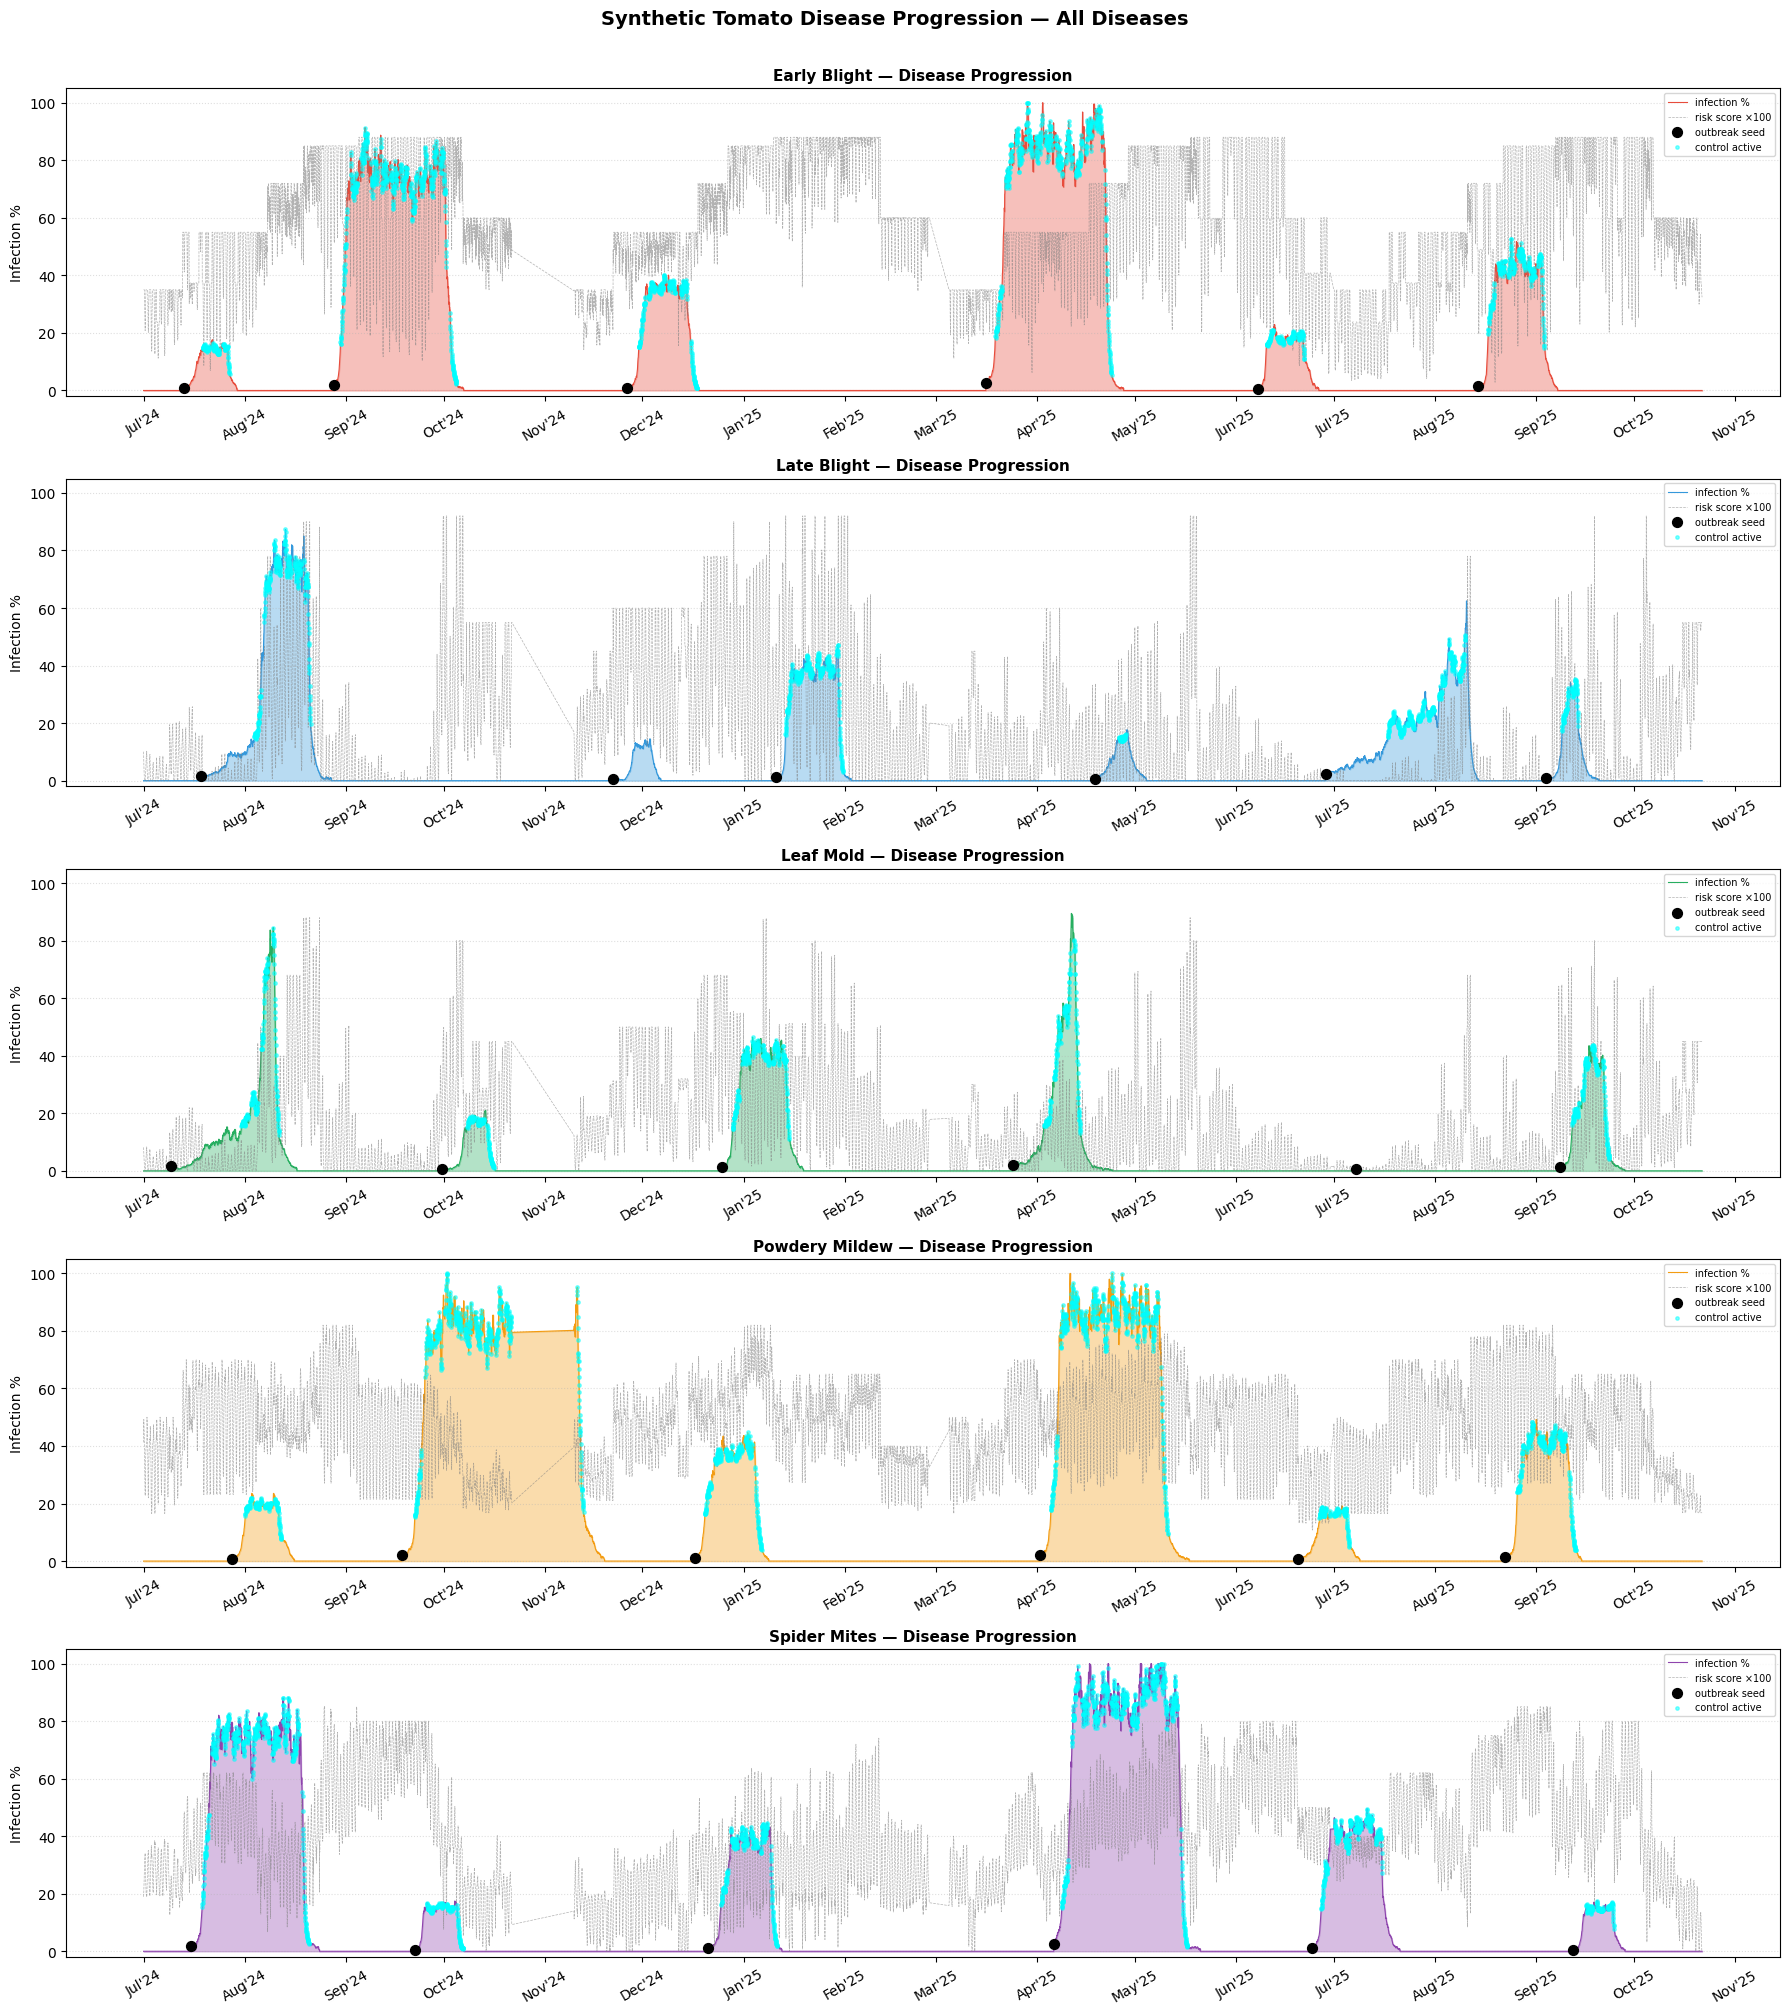

Visualisation rendered inline — no file saved.


In [13]:
# ── Inline Visualisations (progression curves per disease) ────
fig, axes = plt.subplots(len(DISEASES), 1, figsize=(18, 4 * len(DISEASES)), sharex=False)

palette = {
    "early_blight"   : "#e74c3c",
    "late_blight"    : "#3498db",
    "leaf_mold"      : "#27ae60",
    "powdery_mildew" : "#f39c12",
    "spider_mites"   : "#8e44ad",
}

for ax, disease in zip(axes, DISEASES):
    sub  = df_final[df_final["disease_name"] == disease].copy()
    ts   = sub["timestamp"]
    inf  = sub["current_infection_pct"]
    risk = sub["disease_risk_score"] * 100  # scale to same axis

    ax.fill_between(ts, inf, alpha=0.35, color=palette[disease])
    ax.plot(ts, inf, linewidth=0.8, color=palette[disease], label="infection %")
    ax.plot(ts, risk, linewidth=0.5, linestyle="--", color="grey", alpha=0.6, label="risk score ×100")

    # Mark outbreak triggers
    triggers = sub[sub["outbreak_trigger_flag"] == 1]
    ax.scatter(triggers["timestamp"], triggers["current_infection_pct"],
               color="black", s=50, zorder=5, label="outbreak seed")

    # Mark control actions
    ctrl = sub[sub["control_action_flag"] == 1]
    ax.scatter(ctrl["timestamp"], ctrl["current_infection_pct"],
               color="cyan", s=6, zorder=4, alpha=0.5, label="control active")

    ax.set_title(f"{disease.replace('_', ' ').title()} — Disease Progression",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Infection %")
    ax.set_ylim(-2, 105)
    ax.legend(loc="upper right", fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b'%y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.suptitle("Synthetic Tomato Disease Progression — All Diseases",
             fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()
print("Visualisation rendered inline — no file saved.")

In [14]:
# \u2500\u2500 Sanity checks: progression quality \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
print("Progression quality checks:\n")

# Check 1: Mean growth rate per phase
print("  Mean infection_growth_rate_hourly by disease_cycle_stage:")
rate_by_phase = (
    df_final[df_final["disease_cycle_stage"] != "none"]
    .groupby("disease_cycle_stage")["infection_growth_rate_hourly"]
    .mean()
    .round(4)
)
for phase, rate in rate_by_phase.items():
    direction = "\u2191 spreading" if rate > 0 else "\u2193 declining"
    print(f"    {phase:<15}  mean_growth={rate:+.4f}  {direction}")

# Check 2: Mean risk score during active vs healthy periods
active_risk  = df_final[df_final["current_infection_pct"] > 5]["disease_risk_score"].mean()
healthy_risk = df_final[df_final["current_infection_pct"] == 0]["disease_risk_score"].mean()
print(f"\n  Mean disease_risk_score:")
print(f"    During active disease  (>5% infected) : {active_risk:.4f}")
print(f"    During healthy periods (0% infected)  : {healthy_risk:.4f}")

# Check 3: Infection bounds per active phase
print("\n  Infection bounds per phase (spread / severe / decline):")
for phase_label in ("spread", "severe", "decline",):
    sub = df_final[df_final["disease_cycle_stage"] == phase_label]["current_infection_pct"]
    if len(sub) == 0:
        print(f"    {phase_label:<15}  no rows found.")
        continue
    print(f"    {phase_label:<15}  rows={len(sub):,}  "
          f"min={sub.min():.2f}%  mean={sub.mean():.2f}%  max={sub.max():.2f}%  "
          f"{'OK' if sub.min() >= 0 and sub.max() <= 100 else 'FAIL'}")

print("\nProgression quality checks complete.")


Progression quality checks:

  Mean infection_growth_rate_hourly by disease_cycle_stage:
    decline          mean_growth=-0.1198  ↓ declining
    latent           mean_growth=+0.0036  ↑ spreading
    onset            mean_growth=+0.0711  ↑ spreading
    severe           mean_growth=+0.0316  ↑ spreading
    spread           mean_growth=+0.2938  ↑ spreading
    stabilization    mean_growth=-0.4344  ↓ declining

  Mean disease_risk_score:
    During active disease  (>5% infected) : 0.3928
    During healthy periods (0% infected)  : 0.3402

  Infection bounds per phase (spread / severe / decline):
    spread           rows=2,799  min=5.00%  mean=21.99%  max=64.78%  OK
    severe           rows=9,418  min=10.44%  mean=56.24%  max=100.00%  OK
    decline          rows=989  min=0.50%  mean=2.78%  max=62.46%  OK

Progression quality checks complete.


In [15]:
# \u2500\u2500 Final confirmation \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
print("=" * 70)
print("NOTEBOOK EXECUTION COMPLETE")
print("=" * 70)
print(f"  CSV  \u2192 {OUTPUT_CSV}")
print(f"  MD   \u2192 {OUTPUT_MD}")
print()
print("Dataset properties:")
print(f"  Shape           : {df_final.shape[0]:,} rows \u00d7 {df_final.shape[1]} columns")
print(f"  Diseases        : {len(DISEASES)} ({', '.join(DISEASES)})")
print(f"  Cycles/disease  : 6 (2 mild + 2 moderate + 2 severe)")
print(f"  Simulation model: 6-phase (latent->onset->spread->severe->stabilization->decline)")
print()
print("Note: Future prediction targets (24h, 48h) are NOT included.")
print("      They will be generated by a separate downstream process.")
print()
print("Dataset is ready for:")
print("  * Sequence / time-series model training (filter by disease_name)")
print("  * Sliding-window target extraction for any forecast horizon")
print("  * Multi-label disease presence classification")
print("  * Epidemiological trend analysis in greenhouse settings")


NOTEBOOK EXECUTION COMPLETE
  CSV  → E:\AgriTwin-GH\data\processed\Disease Progression\tomato_disease_progression_synthetic_hourly.csv
  MD   → E:\AgriTwin-GH\data\processed\Disease Progression\DISEASE_PROGRESSION_SYNTHETIC_DOCUMENTATION.md

Dataset properties:
  Shape           : 54,240 rows × 39 columns
  Diseases        : 5 (early_blight, late_blight, leaf_mold, powdery_mildew, spider_mites)
  Cycles/disease  : 6 (2 mild + 2 moderate + 2 severe)
  Simulation model: 6-phase (latent->onset->spread->severe->stabilization->decline)

Note: Future prediction targets (24h, 48h) are NOT included.
      They will be generated by a separate downstream process.

Dataset is ready for:
  * Sequence / time-series model training (filter by disease_name)
  * Sliding-window target extraction for any forecast horizon
  * Multi-label disease presence classification
  * Epidemiological trend analysis in greenhouse settings
